In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter
import random
seed=42
np.random.seed(seed)
random.seed(seed)



In [3]:
train_df=pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv')
test_df = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv')
x=train_df.drop('label',axis=1).values
y=train_df['label'].values
x_test=test_df.drop('label',axis=1).values
y_test=test_df['label'].values

In [4]:
x=x/255.0
x_test=x_test/255.0

In [5]:
print(x.shape)

(60000, 784)


In [6]:
x_train, x_val, y_train, y_val=train_test_split(x,y,test_size=0.2,random_state=seed, stratify=y)

In [7]:
print("Training samples: ", x_train.shape[0])
print("Validation samples: ", x_val.shape[0])
print("Test samples: ", x_test.shape[0])

Training samples:  48000
Validation samples:  12000
Test samples:  10000


In [8]:
def class_distribution(labels, name):
    counter=Counter(labels)
    print(f"\n{name} distribution: ")
    for cl, count in sorted(counter.items()):
        print(f"Class {cl} : {count}")
class_distribution(y_train, "Train")
class_distribution(y_val, "Validation")
class_distribution(y_test, "Test")


Train distribution: 
Class 0 : 4800
Class 1 : 4800
Class 2 : 4800
Class 3 : 4800
Class 4 : 4800
Class 5 : 4800
Class 6 : 4800
Class 7 : 4800
Class 8 : 4800
Class 9 : 4800

Validation distribution: 
Class 0 : 1200
Class 1 : 1200
Class 2 : 1200
Class 3 : 1200
Class 4 : 1200
Class 5 : 1200
Class 6 : 1200
Class 7 : 1200
Class 8 : 1200
Class 9 : 1200

Test distribution: 
Class 0 : 1000
Class 1 : 1000
Class 2 : 1000
Class 3 : 1000
Class 4 : 1000
Class 5 : 1000
Class 6 : 1000
Class 7 : 1000
Class 8 : 1000
Class 9 : 1000


<function matplotlib.pyplot.show(close=None, block=None)>

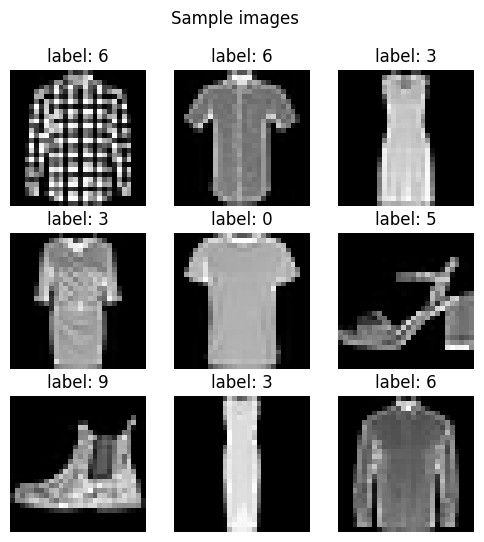

In [9]:
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='grey')
    plt.title(f"label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("Sample images")
plt.show

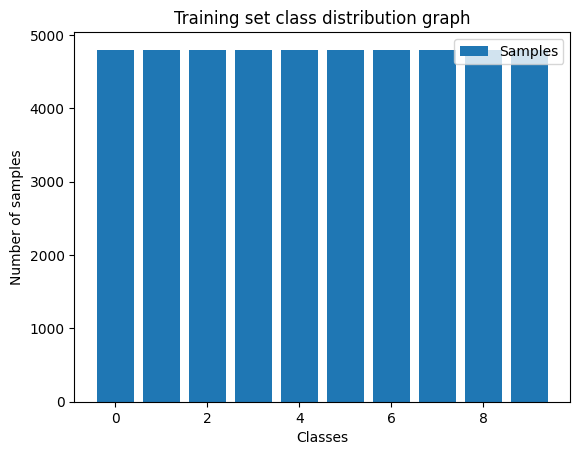

In [10]:
def plot_distribution(labels, title):
    counter=Counter(labels)
    classes=list(counter.keys())
    counts=list(counter.values())
    plt.figure()
    plt.bar(classes, counts)
    plt.xlabel("Classes")
    plt.ylabel("Number of samples")
    plt.title(title)
    plt.legend(["Samples"])
    plt.show()
plot_distribution(y_train, "Training set class distribution graph")

**PART 1**

In [11]:
input_size=784
hidden_size=64
output_size=10
lr=0.01
w1=np.random.randn(input_size,hidden_size)*0.01
b1=np.zeros((1,hidden_size))
w2=np.random.randn(hidden_size,output_size)*0.01
b2=np.zeros((1,output_size))


In [12]:
def relu(x):
    return np.maximum(0,x)
def relu_deriv(x):
    return (x>0).astype(float)
def softmax(x):
    exp=np.exp(x-np.max(x,axis=1, keepdims=True))
    return exp/np.sum(exp,axis=1,keepdims=True)

In [13]:
def forward(x):
    z1=x@w1+b1
    a1=relu(z1)
    z2=a1@w2+b2
    a2=softmax(z2)
    return z1, a1,z2,a2
    

In [14]:
def compute_loss(y_true, y_pred):
    n=y_true.shape[0]
    log_like=-np.log(y_pred[range(n),y_true]+1e-9)
    return np.mean(log_like)

In [15]:
def backward(x, y, z1, a1, a2):
    n = x.shape[0]
    y_onehot = np.zeros_like(a2)
    y_onehot[np.arange(n), y] = 1
    dz2 = (a2 - y_onehot) / n
    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)
    da1 = dz2 @ w2.T
    dz1 = da1 * relu_deriv(z1)
    dW1 = x.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)
    return dW1, db1, dW2, db2

In [16]:
def update(dW1, db1, dW2, db2):
    global w1, b1, w2, b2
    w1 -= lr * dW1
    b1 -= lr * db1
    w2 -= lr * dW2
    b2 -= lr * db2

In [17]:
X_sub = x_train[:5000]
y_sub = y_train[:5000]
losses = []
for epoch in range(20):
    z1, a1, z2, a2 = forward(X_sub)
    loss = compute_loss(y_sub, a2)
    losses.append(loss)
    dW1, db1, dW2, db2 = backward(X_sub, y_sub, z1, a1, a2)
    update(dW1, db1, dW2, db2)
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

Epoch 1, Loss: 2.3044
Epoch 2, Loss: 2.3043
Epoch 3, Loss: 2.3041
Epoch 4, Loss: 2.3039
Epoch 5, Loss: 2.3038
Epoch 6, Loss: 2.3036
Epoch 7, Loss: 2.3035
Epoch 8, Loss: 2.3033
Epoch 9, Loss: 2.3031
Epoch 10, Loss: 2.3030
Epoch 11, Loss: 2.3028
Epoch 12, Loss: 2.3026
Epoch 13, Loss: 2.3025
Epoch 14, Loss: 2.3023
Epoch 15, Loss: 2.3022
Epoch 16, Loss: 2.3020
Epoch 17, Loss: 2.3018
Epoch 18, Loss: 2.3017
Epoch 19, Loss: 2.3015
Epoch 20, Loss: 2.3014


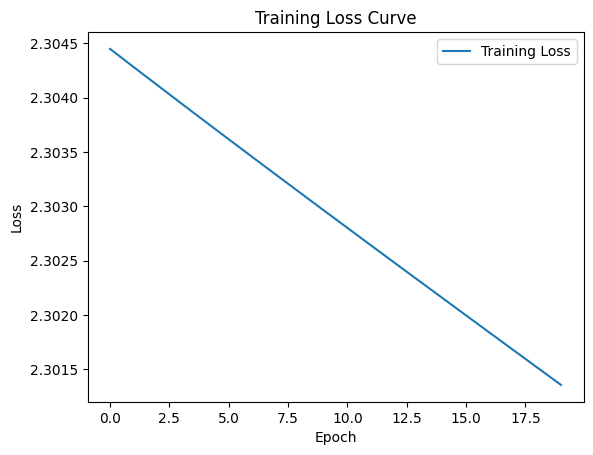

In [18]:
plt.plot(losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.show()

gradient check with pytorch

In [19]:
import torch
import torch.nn as nn
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(784, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

In [20]:
with torch.no_grad():
    model[0].weight.copy_(torch.tensor(w1.T))
    model[0].bias.copy_(torch.tensor(b1.flatten()))  
    model[2].weight.copy_(torch.tensor(w2.T))
    model[2].bias.copy_(torch.tensor(b2.flatten()))

In [21]:
X_t = torch.tensor(X_sub[:32], dtype=torch.float32)
y_t = torch.tensor(y_sub[:32], dtype=torch.long)
criterion = nn.CrossEntropyLoss()
out = model(X_t)
loss_t = criterion(out, y_t)
loss_t.backward()

In [22]:
z1, a1, z2, a2 = forward(X_sub[:32])
dW1, db1, dW2, db2 = backward(X_sub[:32], y_sub[:32], z1, a1, a2)
torch_dW1 = model[0].weight.grad.numpy().T
torch_dW2 = model[2].weight.grad.numpy().T
print("Max diff W1:", np.max(np.abs(dW1 - torch_dW1)))
print("Max diff W2:", np.max(np.abs(dW2 - torch_dW2)))

Max diff W1: 6.716957363581133e-10
Max diff W2: 4.555182293863869e-09


the max abs difference between numpy and pytorch gradients is in 10^-10 which is extremely small confirming the backpropagation is correct and numerically stable.

**part 2**

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
class MLP(nn.Module):
    def __init__(self, activation):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.act1 = activation
        self.fc2 = nn.Linear(128, 64)
        self.act2 = activation
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.act1(self.fc1(x))
        x = self.act2(self.fc2(x))
        x = self.fc3(x)
        return x

In [24]:
activations = {
    "sigmoid": nn.Sigmoid(),
    "tanh": nn.Tanh(),
    "relu": nn.ReLU(),
    "leaky_relu": nn.LeakyReLU(0.01)
}

In [25]:
def train_model(model, X_train, y_train, X_val, y_val):
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()
    val_losses = []
    for epoch in range(20):
        model.train()
        out = model(X_train)
        loss = criterion(out, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        model.eval()
        with torch.no_grad():
            val_out = model(X_val)
            val_loss = criterion(val_out, y_val)
            val_losses.append(val_loss.item())

    return val_losses

In [26]:
results = {}
X_t = torch.tensor(x_train[:5000], dtype=torch.float32)
y_t = torch.tensor(y_train[:5000], dtype=torch.long)
X_v = torch.tensor(x_val[:1000], dtype=torch.float32)
y_v = torch.tensor(y_val[:1000], dtype=torch.long)
for name, act in activations.items():
    model = MLP(act)
    losses = train_model(model, X_t, y_t, X_v, y_v)
    results[name] = losses

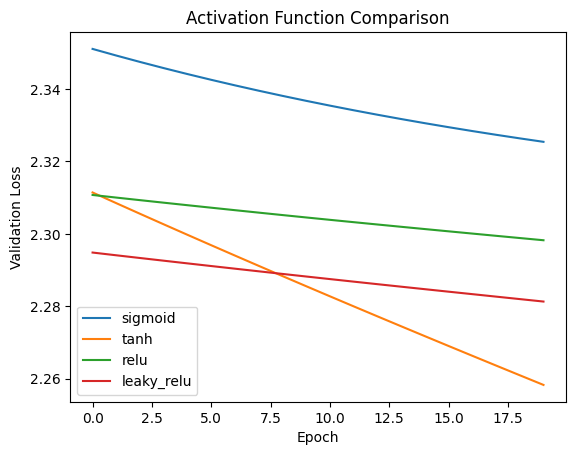

In [27]:
for name, losses in results.items():
    plt.plot(losses, label=name)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Activation Function Comparison")
plt.legend()
plt.show()

Tanh achieved the lowest validation maybe due to its zero centered output, which can improve gradient flow compared to sigmoid. Relu and Leaky Relu also performed well  while sigmoid showed the slowest improvement due to vanishing gradients.

In [28]:
def get_gradients(model, X, y):
    criterion = nn.CrossEntropyLoss()
    out = model(X)
    loss = criterion(out, y)
    model.zero_grad()
    loss.backward()
    grad = model.fc1.weight.grad.abs().mean().item()
    return grad

In [29]:
model_sig = MLP(nn.Sigmoid())
g1_sig = get_gradients(model_sig, X_t, y_t)
train_model(model_sig, X_t, y_t, X_v, y_v)
gfinal_sig = get_gradients(model_sig, X_t, y_t)
model_relu = MLP(nn.ReLU())
g1_relu = get_gradients(model_relu, X_t, y_t)
train_model(model_relu, X_t, y_t, X_v, y_v)
gfinal_relu = get_gradients(model_relu, X_t, y_t)

In [30]:
def dead_relu_percentage(model, X):
    with torch.no_grad():
        h1 = model.act1(model.fc1(X))
        dead = (h1 == 0).all(dim=0) 
        return dead.float().mean().item() * 100

In [31]:
dead_pct = dead_relu_percentage(model_relu, X_v)
print("Dead units %:", dead_pct)

Dead units %: 0.78125


~0.78% of ReLU units were inactive for all inputs, indicating a very small number of dead neurons. This suggests that most neurons remained active and contributed to learning.

**part 3**

In [32]:
torch.manual_seed(42)
model_ce = MLP(nn.ReLU())
optimizer = optim.SGD(model_ce.parameters(), lr=0.01,  momentum=0.9)
criterion_ce = nn.CrossEntropyLoss()

In [33]:
ce_losses = []
for epoch in range(300):
    out = model_ce(X_t)
    loss = criterion_ce(out, y_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    ce_losses.append(loss.item())

In [34]:
with torch.no_grad():
    preds = model_ce(torch.tensor(x_test, dtype=torch.float32))
    predicted = preds.argmax(dim=1).numpy()
acc_ce = (predicted == y_test).mean()
print("CE Accuracy:", acc_ce)

CE Accuracy: 0.8067


In [35]:
def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]
y_t_oh = torch.tensor(one_hot(y_train[:5000]), dtype=torch.float32)

In [36]:
torch.manual_seed(42)
model_mse = MLP(nn.ReLU())
optimizer = optim.SGD(model_mse.parameters(), lr=0.01,  momentum=0.9)
criterion_mse = nn.MSELoss()
mse_losses = []
for epoch in range(300):
    out = model_mse(X_t)
    probs = torch.softmax(out, dim=1)  
    loss = criterion_mse(probs, y_t_oh)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    mse_losses.append(loss.item())

In [37]:
with torch.no_grad():
    preds = model_mse(torch.tensor(x_test, dtype=torch.float32))
    predicted = preds.argmax(dim=1).numpy()
acc_mse = (predicted == y_test).mean()
print("MSE Accuracy:", acc_mse)

MSE Accuracy: 0.1975


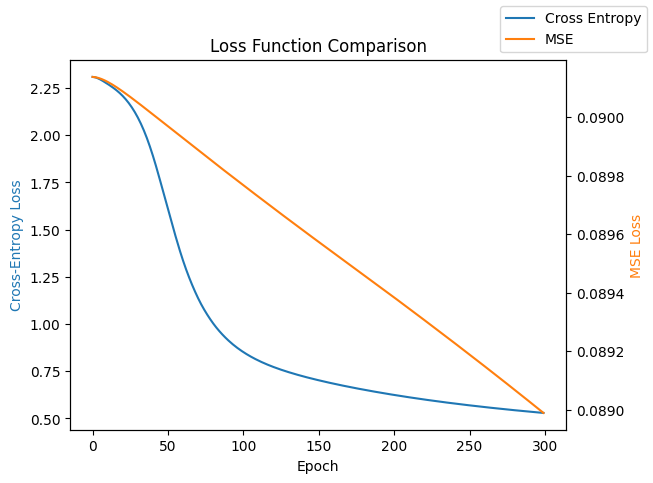

In [38]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(ce_losses, color="tab:blue", label="Cross Entropy")
ax2.plot(mse_losses, color="tab:orange", label="MSE")
ax1.set_ylabel("Cross-Entropy Loss", color="tab:blue")
ax2.set_ylabel("MSE Loss", color="tab:orange")
ax1.set_xlabel("Epoch")
plt.title("Loss Function Comparison")
fig.legend(loc="upper right")
plt.show()

With softmax + cross-entropy, the gradient at the output layer simplifies to (prediction − target), giving a large, constant scale error signal even when the model is confidently wrong; with MSE on softmax outputs, that same error gets multiplied by the softmax derivative, which is near zero when a unit is saturated (confidently wrong or right), so wrong but confident predictions get almost no gradient and learning stalls. 

In [39]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
data = fetch_california_housing()
X_reg = data.data
y_reg = data.target
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
scaler_X = StandardScaler()
X_train_r = scaler_X.fit_transform(X_train_r)
X_test_r = scaler_X.transform(X_test_r)
scaler_y = StandardScaler()
y_train_r = scaler_y.fit_transform(y_train_r.reshape(-1, 1))
y_test_r = scaler_y.transform(y_test_r.reshape(-1, 1))


In [40]:
model_reg = nn.Sequential(
    nn.Linear(X_train_r.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)
optimizer = optim.SGD(model_reg.parameters(), lr=0.01)
criterion = nn.MSELoss()
Xtr = torch.tensor(X_train_r, dtype=torch.float32)
ytr = torch.tensor(y_train_r, dtype=torch.float32)  # already (N,1) shape

for epoch in range(50):
    out = model_reg(Xtr)
    loss = criterion(out, ytr)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
Xte = torch.tensor(X_test_r, dtype=torch.float32)
with torch.no_grad():
    preds_scaled = model_reg(Xte).numpy()
preds = scaler_y.inverse_transform(preds_scaled)
y_test_real = scaler_y.inverse_transform(y_test_r)


In [41]:

mse = mean_squared_error(y_test_real, preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_real, preds)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

MSE: 0.8264073609917901
RMSE: 0.909069502838914
MAE: 0.7101208970611732


**part 4**

In [42]:
import time

def get_optimizer(name, model, lr):
    if name == "sgd":
        return optim.SGD(model.parameters(), lr=lr)
    if name == "sgd_momentum":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    if name == "rmsprop":
        return optim.RMSprop(model.parameters(), lr=lr)
    if name == "adam":
        return optim.Adam(model.parameters(), lr=lr)

In [43]:
def train_optimizer(name, lr, epochs=500):
    torch.manual_seed(42)
    model = MLP(nn.ReLU())
    optimizer = get_optimizer(name, model, lr)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    epoch_85 = None
    start = time.time()

    for epoch in range(epochs):
        out = model(X_t)
        loss = criterion(out, y_t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        with torch.no_grad():
            val_out = model(X_v)
            val_acc = (val_out.argmax(dim=1) == y_v).float().mean().item()
        if epoch_85 is None and val_acc >= 0.85:
            epoch_85 = epoch + 1

    elapsed = time.time() - start
    return train_losses, epoch_85, elapsed, val_acc

run 1: same learning rate for all optimisers

In [44]:
optimizer_names = ["sgd", "sgd_momentum", "rmsprop", "adam"]
run1 = {}

for name in optimizer_names:
    losses, ep85, t, vacc = train_optimizer(name, lr=0.01)
    run1[name] = {"losses": losses, "epoch_85": ep85, "time": t, "val_acc": vacc}
    print(name, "-> epoch_85:", ep85, ", time:", round(t, 2), "s, final val acc:", round(vacc, 4))

sgd -> epoch_85: None , time: 14.68 s, final val acc: 0.614
sgd_momentum -> epoch_85: None , time: 14.68 s, final val acc: 0.815
rmsprop -> epoch_85: None , time: 14.75 s, final val acc: 0.81
adam -> epoch_85: None , time: 15.33 s, final val acc: 0.825


run 2: learning rate search per optimiser

In [45]:
lr_grid = {
    "sgd": [0.05, 0.1, 0.3],
    "sgd_momentum": [0.02, 0.05, 0.1],
    "rmsprop": [0.001, 0.005, 0.01],
    "adam": [0.001, 0.005, 0.01]
}

search_results = {}
for name, lrs in lr_grid.items():
    for lr in lrs:
        losses, ep85, t, vacc = train_optimizer(name, lr=lr)
        search_results[(name, lr)] = vacc
        print(name, lr, "-> val acc:", round(vacc, 4), ", epoch_85:", ep85)

sgd 0.05 -> val acc: 0.776 , epoch_85: None
sgd 0.1 -> val acc: 0.777 , epoch_85: None
sgd 0.3 -> val acc: 0.841 , epoch_85: None
sgd_momentum 0.02 -> val acc: 0.828 , epoch_85: None
sgd_momentum 0.05 -> val acc: 0.826 , epoch_85: None
sgd_momentum 0.1 -> val acc: 0.828 , epoch_85: None
rmsprop 0.001 -> val acc: 0.827 , epoch_85: None
rmsprop 0.005 -> val acc: 0.837 , epoch_85: None
rmsprop 0.01 -> val acc: 0.81 , epoch_85: None
adam 0.001 -> val acc: 0.821 , epoch_85: None
adam 0.005 -> val acc: 0.829 , epoch_85: None
adam 0.01 -> val acc: 0.825 , epoch_85: None


final tuned run — best lr per optimiser, extended epochs

In [46]:
best_lr = {
    "sgd": 0.3,
    "sgd_momentum": 0.1,
    "rmsprop": 0.005,
    "adam": 0.005
}

final_results = {}
for name, lr in best_lr.items():
    losses, ep85, t, vacc = train_optimizer(name, lr=lr, epochs=1500)
    final_results[name] = {"lr": lr, "losses": losses, "epoch_85": ep85, "time": t, "val_acc": vacc}
    print(name, "-> lr:", lr, ", epoch_85:", ep85, ", time:", round(t, 2), "s, final val acc:", round(vacc, 4))

sgd -> lr: 0.3 , epoch_85: None , time: 43.34 s, final val acc: 0.817
sgd_momentum -> lr: 0.1 , epoch_85: None , time: 43.55 s, final val acc: 0.812
rmsprop -> lr: 0.005 , epoch_85: None , time: 44.56 s, final val acc: 0.82
adam -> lr: 0.005 , epoch_85: None , time: 45.05 s, final val acc: 0.825


none of the optimisers reached 85% validation accuracy within 1500 full-batch epochs on the 5000-sample subset, likely due to the small training set and full-batch updates limiting how far the model can generalise. reporting final validation accuracy instead as the comparison metric.

In [48]:
import pandas as pd

table = pd.DataFrame({
    "Optimiser": ["SGD", "SGD + momentum", "RMSProp", "Adam"],
    "Learning rate": [final_results["sgd"]["lr"], final_results["sgd_momentum"]["lr"],
                       final_results["rmsprop"]["lr"], final_results["adam"]["lr"]],
    "Epochs to 85% val acc": ["not reached", "not reached", "not reached", "not reached"],
    "Wall-clock time (s)": [round(final_results["sgd"]["time"], 2), round(final_results["sgd_momentum"]["time"], 2),
                             round(final_results["rmsprop"]["time"], 2), round(final_results["adam"]["time"], 2)],
    "Final val accuracy": [round(final_results["sgd"]["val_acc"], 4), round(final_results["sgd_momentum"]["val_acc"], 4),
                            round(final_results["rmsprop"]["val_acc"], 4), round(final_results["adam"]["val_acc"], 4)]
})
table

,Optimiser,Learning rate,Epochs to 85% val acc,Wall-clock time (s),Final val accuracy
0,SGD,0.300,not reached,43.34,0.817
1,SGD + momentum,0.100,not reached,43.55,0.812
2,RMSProp,0.005,not reached,44.56,0.820
3,Adam,0.005,not reached,45.05,0.825


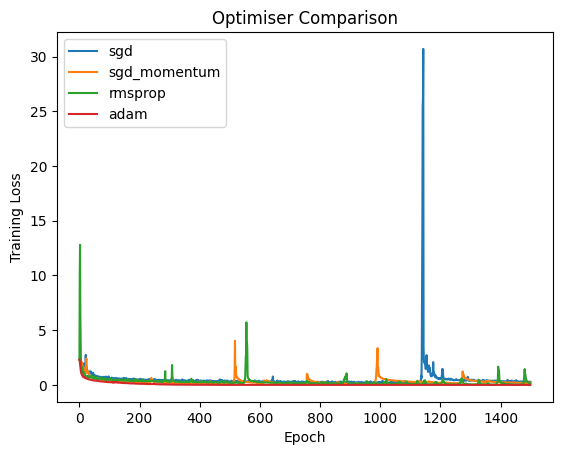

In [49]:
for name in best_lr.keys():
    plt.plot(final_results[name]["losses"], label=name)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Optimiser Comparison")
plt.legend()
plt.show()

Adam gave the best final validation accuracy (82.5%) and the most stable training curve, with almost no loss spikes compared to SGD and RMSProp which both showed sharp instability at their tuned learning rates. SGD required the largest learning rate (0.3) to be competitive at all, and even then produced the biggest spike in training loss, suggesting it is far more sensitive to learning rate choice than the adaptive optimisers.